# Planning Report
project-009-33
Data description
Summary of the dataset：The gaming team is collecting gameplay data from video game players.
number of variable:age, gender, total playtime, experience level, and whether they subscribed to a game-related newsletter.
the number of observations: Whether to subscribe to the game， 1
summary statistics (report values to 2 decimal places)
number of variables：5
name and type of variables:
1.subscribe: Whether the player subscribed to the newsletter?(Yes=1, No=0)
2.play_hours:total hours about the player spent in the game.
3.gender:woman or man
4.age:player’s age in years
5.experience: player’s level of playing the game.


Problems
Will people of different ages subscribe? Are older people or younger people more likely to subscribe? Can the length of time people spend playing games determine whether they will subscribe to a game? 

Which factors(age, gender, playtime, experience) are the strongest predictors of newsletter subscriptions?

Hypotheses
H1: Players with more play hours are more likely to subscribe to the newsletter.
H2: Different gender have different subscription.
H3: Older people are more willing to subscribe.
H4:Veteran is more willing to subscribe.


Methods
We can use the linear regression model was to predict outcome subscribe. Regression model estimates the probability that a player subscribes, given their demographic and behavioral characteristics.
Why appropriate: Linear regression is simple, interpretable, and allows us to quantify the effect of each predictor on the response variable.
Limitations: There may be significant differences, such as between the minimum and maximum values. The error is relatively large.
I will choose to split the data. I will split it into training data and testing data. The proportions of these two datasets will be different. I will split it into a 40/60 ratio. I will use cross-validation.



In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
players<- read_csv("players.csv")
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


In [3]:
numeric_means <- players |>
  select(where(is.numeric)) |>
  summarise(across(everything(), ~ round(mean(.x, na.rm = TRUE))))
numeric_means

played_hours,Age
<dbl>,<dbl>
6,21


In [4]:
age_summary <- players |>
  group_by(Age) |>
  summarise(total_played_hours = sum(played_hours, na.rm = TRUE))|>
  ungroup()

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


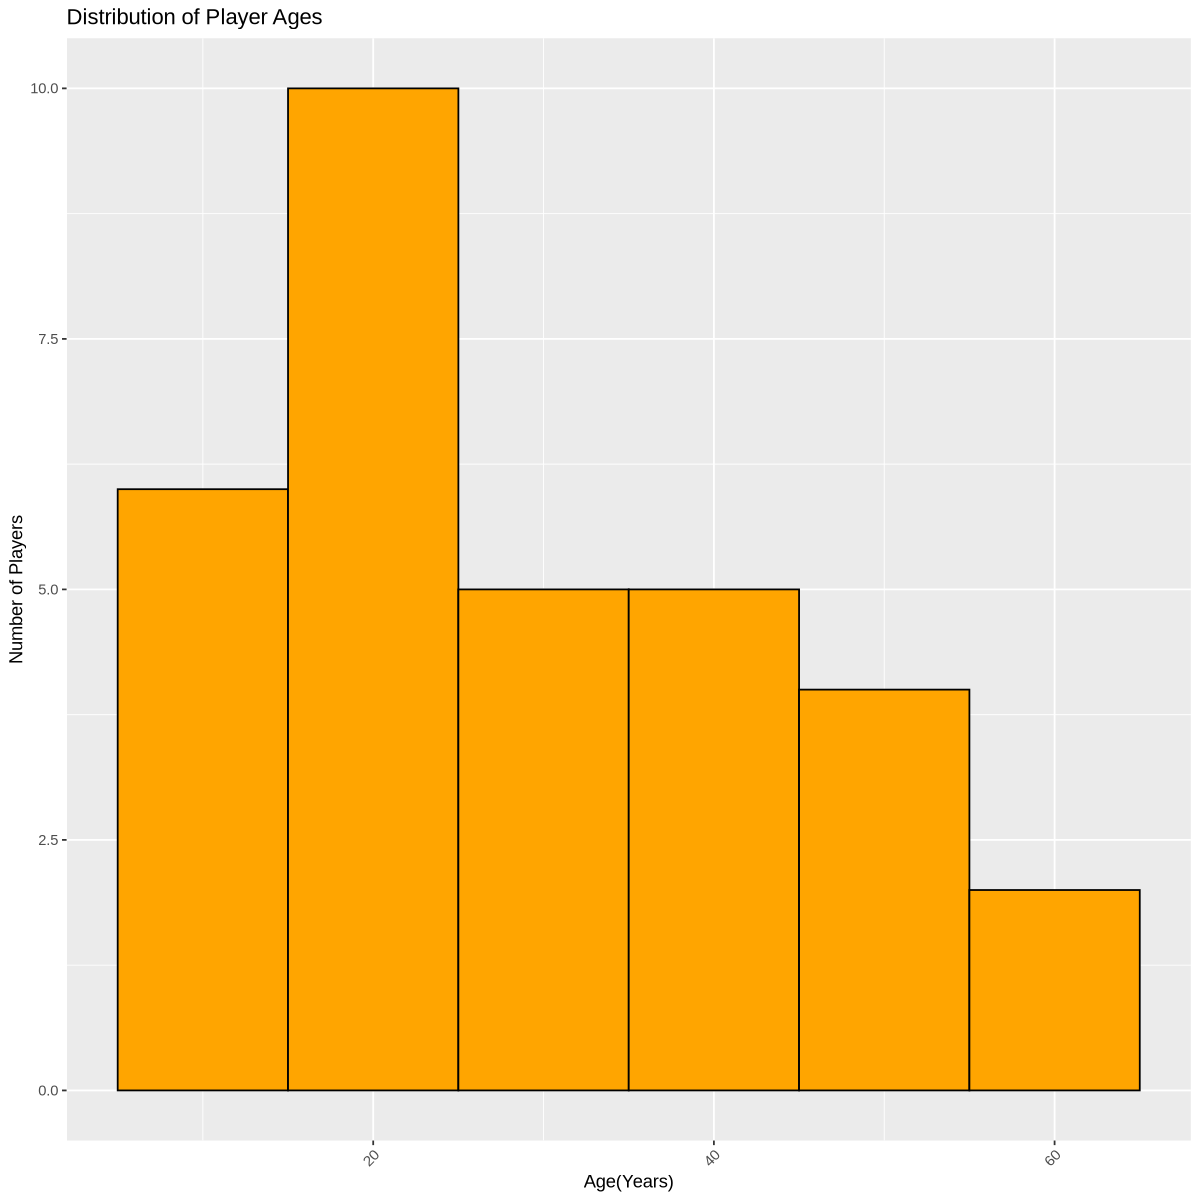

In [5]:
options(repr.plot.width = 10, repr.plot.height =10)
count_bar_chart <- ggplot(age_summary, aes(x = Age)) + 
   geom_histogram(binwidth = 10, fill = "orange", color = "black") +
   xlab("Age(Years)") +
   ylab("Number of Players")+
    ggtitle("Distribution of Player Ages")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

count_bar_chart

In [1]:
#The largest group of players is around 20 years old. The older the player, the fewer players there are.

In [2]:
age_plot<-ggplot(players, aes(x = Age, y = played_hours)) +
  geom_point(alpha = 0.7) +
  xlab("Age (Years)") +
  ylab("Played Hours") +
  ggtitle("Age vs Played Hours by Player Type") 
age_plot

ERROR: Error in ggplot(players, aes(x = Age, y = played_hours)): could not find function "ggplot"


In [3]:
age_plot

ERROR: Error in eval(expr, envir, enclos): object 'age_plot' not found
